# Customer Segmentation with RFM Analysis and Unsupervised Learning

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Aprendizado Não Supervisionado<br />
> **Author:** Augusto Stahlschmidt<br />
> **Date:** September 25, 2025   

---

## 1. Introduction & Objectives

**Problem:**  
Online retailers generate hundreds of thousands of transactions per year but typically lack a structured approach to differentiate customers by purchasing behavior. Undifferentiated marketing wastes resources and misses revenue opportunities. Clustering-based segmentation enables targeted strategies tailored to each behavioral profile.

**Task Type:**  
Unsupervised Learning, Clustering

**Business or Research Objective:**  
Apply RFM (Recency, Frequency, Monetary) analysis combined with three clustering algorithms (K-Means, Agglomerative Hierarchical, DBSCAN) to identify distinct customer segments, and translate results into actionable business profiles aligned with classical RFM archetypes (Champions, Loyal, At Risk, Lost).

**Analytical Goal:**  
Compare algorithms using internal validation metrics, select the best configuration, and produce interpretable cluster profiles visualized via PCA scatter plots, radar charts, heatmaps, and revenue distribution plots.

**Primary Evaluation Metrics:**  
Silhouette Score (higher is better, range: -1 to 1) and Davies-Bouldin Index (lower is better, range: ≥ 0).

**Success Criteria:**  
Identify 4–6 distinct, interpretable customer segments with Silhouette Score > 0.30. The final segmentation must map to recognizable RFM archetypes.

## 2. Setup & Imports

In [1]:
# Required packages (install if needed):
#   pip install ucimlrepo plotly seaborn scikit-learn scipy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from time import time
from ucimlrepo import fetch_ucirepo

# Reproducibility
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

print("Environment ready")

Environment ready


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[UCI Machine Learning Repository — Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)

**Description:**  
541,909 transactions from a UK-based online retailer, spanning December 2010 to December 2011. Each row represents one line item in an invoice.

**Features:**

| # | Column | Type | Description | Used in RFM |
|---|---|---|---|:---:|
| 1 | Description | string | Product name; used as proxy for line-item count in Frequency | Yes |
| 2 | Quantity | int | Number of units per transaction line | Yes |
| 3 | InvoiceDate | datetime | Date and time of the invoice; used to compute Recency | Yes |
| 4 | UnitPrice | float | Price per unit in GBP (£) | Yes |
| 5 | CustomerID | float | Unique customer identifier; missing in ~24.9% of rows | Yes |
| 6 | Country | string | Country where the customer resides | No |


**Unit of Analysis (after preprocessing):**  
Individual customer, characterized by their aggregated RFM metrics.

**Notes:**  
- Around 25% of rows lack `CustomerID` and will be excluded. Negative `Quantity` and non-positive `UnitPrice` values represent returns or data errors and will be filtered.

In [2]:
# Fetch dataset from UCI repository
online_retail = fetch_ucirepo(id=352)

df = pd.DataFrame(online_retail.data.features, columns=online_retail.feature_names)

print(f"Raw dataset shape : {df.shape}")
print(f"Columns           : {list(df.columns)}")
print()
print("Data types:")
display(df.dtypes.to_frame('dtype'))
print()
print("Sample rows:")
display(df.head())

Raw dataset shape : (541909, 6)
Columns           : ['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:


,dtype
Description,str
Quantity,int64
InvoiceDate,str
UnitPrice,float64
CustomerID,float64
Country,str



Sample rows:


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 4. Exploratory Data Analysis (EDA)

Goals:
- Understand geographic distribution of transactions
- Quantify data quality issues (missing values, returns, errors)
- Motivate the RFM feature construction and preprocessing choices

In [3]:
# Missing values per column
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("Columns with missing values:")
display(miss_df)

Columns with missing values:


,Missing Count,Missing %
CustomerID,135080,24.9
Description,1454,0.3


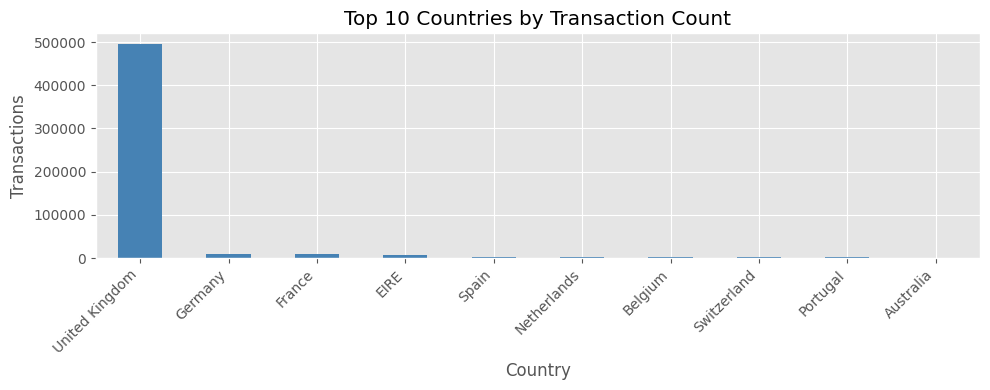

In [4]:
# Top 10 countries by transaction count
fig, ax = plt.subplots(figsize=(10, 4))
df['Country'].value_counts().head(10).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 Countries by Transaction Count')
ax.set_ylabel('Transactions')
ax.set_xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**EDA Findings:**

- The UK dominates the dataset (the vast majority of transactions), followed by Germany, France, and Ireland. The dataset is UK-centric, which limits geographic generalizability.
- Approximately 25% of transactions lack a `CustomerID`. These cannot be attributed to individual customers and must be excluded from RFM analysis — a significant but unavoidable data loss.
- Negative `Quantity` values represent returns or cancellations. Zero/negative `UnitPrice` entries are likely data errors. Both categories distort RFM metrics and must be removed.
- The combination of missing customer IDs and invalid transaction rows results in a substantially smaller usable dataset, but sufficient for meaningful segmentation.

## 5. Preprocessing & Feature Engineering

**Steps performed:**

1. **Data cleaning:** Remove rows with missing `CustomerID`, non-positive `Quantity`, and non-positive `UnitPrice`. Parse `InvoiceDate` as datetime.
2. **RFM construction:** Aggregate each customer's transaction history into three behavioral metrics:
   - `Recency` — days since last purchase (relative to the day after the most recent invoice)
   - `Frequency` — total number of purchase lines
   - `Monetary` — total revenue (Quantity × UnitPrice)
3. **Log transformation:** Apply `log(1 + x)` to `Monetary` to reduce right skew caused by high-spending outliers. Recency and Frequency are left untransformed as RobustScaler handles outliers.
4. **Scaling:** Apply `RobustScaler` to all three RFM features to center and scale without being distorted by extreme values. This is preferred over StandardScaler for this dataset given the outlier-heavy distributions.

In [5]:
# Data cleaning
print(f"Before cleaning: {df.shape}")
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
print(f"After cleaning  : {df.shape}")

Before cleaning: (541909, 6)
After cleaning  : (397884, 6)


In [6]:
# RFM construction
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Description', 'count'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(f"Unique customers in RFM table: {len(rfm)}")
print(f"Snapshot date               : {snapshot_date.date()}")
print()
display(rfm.describe().round(2))

Unique customers in RFM table: 4338
Snapshot date               : 2011-12-10



,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,91.72,2054.27
std,100.01,228.79,8989.23
min,1.00,1.00,3.75
25%,18.00,17.00,307.41
50%,51.00,41.00,674.48
75%,142.00,100.00,1661.74
max,374.00,7847.00,280206.02


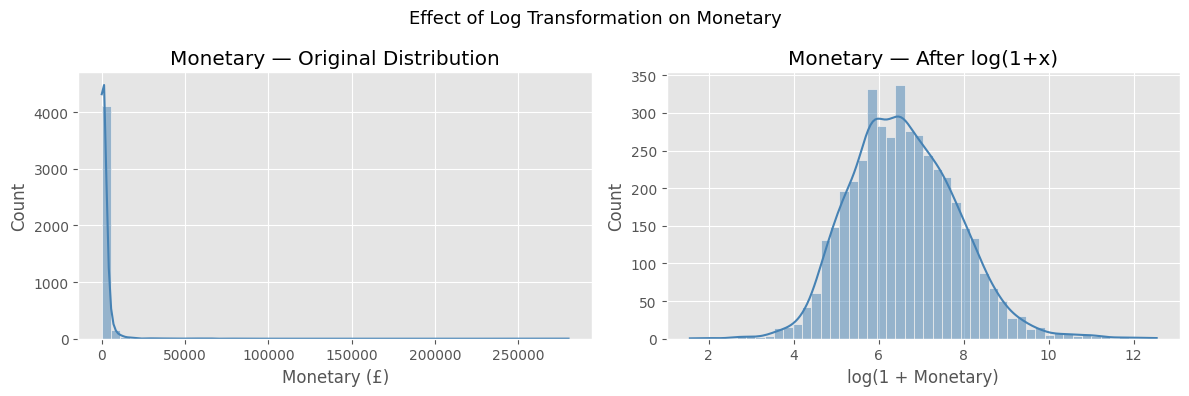


Scaled RFM statistics:


,Recency,Frequency,Monetary_log
count,4338.000,4338.000,4338.000
mean,0.335,0.611,0.046
std,0.807,2.756,0.746
min,-0.403,-0.482,-2.942
25%,-0.266,-0.289,-0.465
50%,0.000,0.000,0.000
75%,0.734,0.711,0.535
max,2.605,94.048,3.578


In [7]:
# Log transform Monetary and scale all features
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

features = ['Recency', 'Frequency', 'Monetary_log']
scaler = RobustScaler()
X = scaler.fit_transform(rfm[features])

# Distribution: original vs log-transformed Monetary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(rfm['Monetary'], bins=50, ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Monetary — Original Distribution')
axes[0].set_xlabel('Monetary (£)')

sns.histplot(rfm['Monetary_log'], bins=50, ax=axes[1], kde=True, color='steelblue')
axes[1].set_title('Monetary — After log(1+x)')
axes[1].set_xlabel('log(1 + Monetary)')

plt.suptitle('Effect of Log Transformation on Monetary', fontsize=13)
plt.tight_layout()
plt.show()

rfm_scaled = pd.DataFrame(X, columns=features, index=rfm.index)
print("\nScaled RFM statistics:")
display(rfm_scaled.describe().round(3))

## 6. Clustering

Three algorithms are applied to the same scaled RFM feature matrix `X` and evaluated using the same internal validation metrics:

| Algorithm | Key Hyperparameter | Selection Method |
|---|---|---|
| K-Means | `k` (number of clusters) | Elbow Method + Silhouette Score |
| Agglomerative Hierarchical | Linkage method (`ward`, `complete`, `average`) | Dendrogram visual inspection |
| DBSCAN | `eps` (neighborhood radius) | k-distance graph |

All results (labels, metrics, runtime) are stored in a unified `results` dictionary for direct comparison.

In [8]:
# Shared results container for all algorithms
results = {
    'algorithm': [],
    'n_clusters': [],
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': [],
    'time': [],
    'labels': []
}

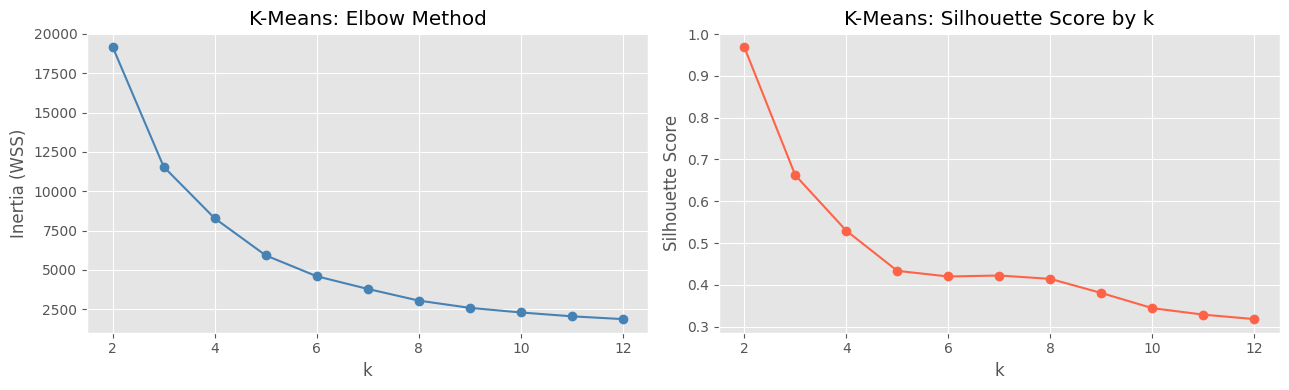

In [9]:
# ==============================================================================
# K-MEANS: Elbow Method + Silhouette Score across k = 2..12
# ==============================================================================
k_range = range(2, 13)
sil_scores = []
inertia_values = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    t0 = time()
    labels = km.fit_predict(X)
    elapsed = time() - t0

    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    results['algorithm'].append(f'KMeans {k} n_clusters')
    results['n_clusters'].append(k)
    results['silhouette'].append(sil)
    results['davies_bouldin'].append(db)
    results['calinski_harabasz'].append(ch)
    results['time'].append(elapsed)
    results['labels'].append(labels)

    sil_scores.append(sil)
    inertia_values.append(km.inertia_)

# Elbow and Silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertia_values, '-o', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (WSS)')
axes[0].set_title('K-Means: Elbow Method')

axes[1].plot(k_range, sil_scores, '-o', color='tomato')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means: Silhouette Score by k')

plt.tight_layout()
plt.show()

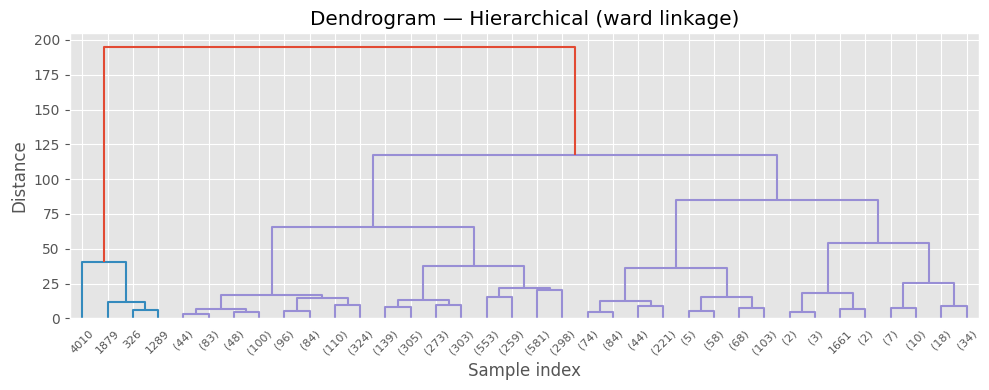

ward       — n_clusters: 4, silhouette: 0.4722, DB: 0.6387


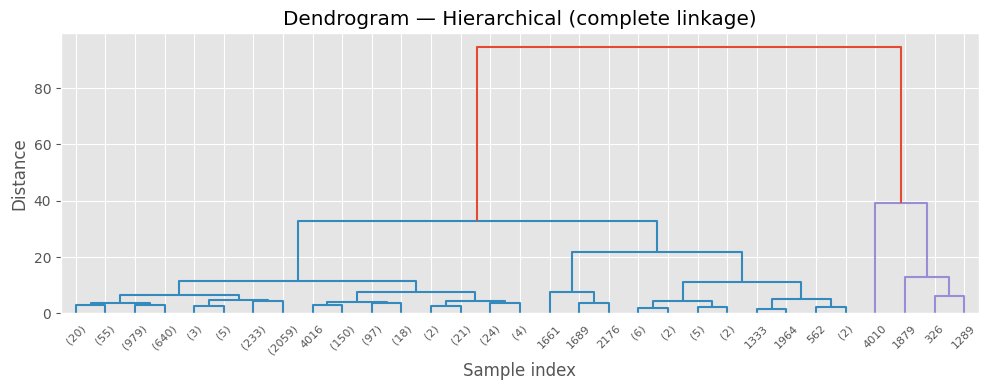

complete   — n_clusters: 4, silhouette: 0.8663, DB: 0.2826


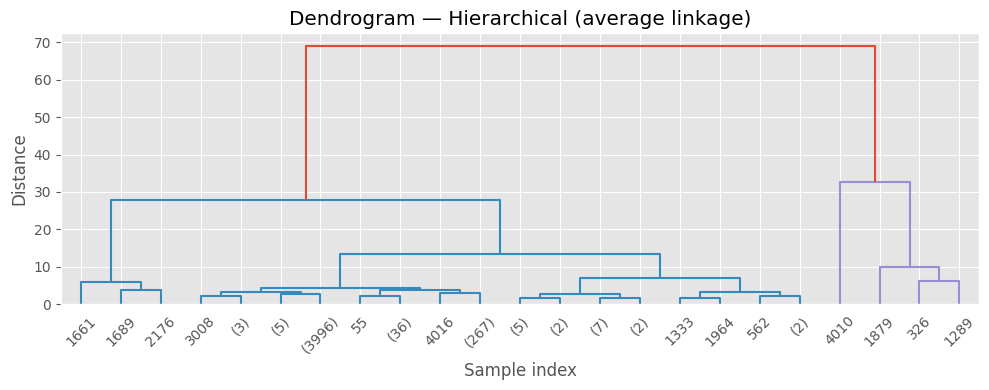

average    — n_clusters: 4, silhouette: 0.9232, DB: 0.1762


In [10]:
# ==============================================================================
# AGGLOMERATIVE HIERARCHICAL CLUSTERING
# Three linkage methods, fixed at n_clusters = 4
# ==============================================================================
linkage_methods = ['ward', 'complete', 'average']
n_clusters_hier = 4

for method in linkage_methods:
    t0 = time()
    Z = linkage(X, method=method)

    plt.figure(figsize=(10, 4))
    dendrogram(Z, truncate_mode='level', p=5)
    plt.title(f'Dendrogram — Hierarchical ({method} linkage)')
    plt.xlabel('Sample index')
    plt.ylabel('Distance')
    plt.tight_layout()
    plt.show()

    labels = fcluster(Z, t=n_clusters_hier, criterion='maxclust')
    elapsed = time() - t0

    n_cls = len(np.unique(labels))
    sil = silhouette_score(X, labels) if n_cls > 1 else np.nan
    db  = davies_bouldin_score(X, labels) if n_cls > 1 else np.nan
    ch  = calinski_harabasz_score(X, labels) if n_cls > 1 else np.nan

    results['algorithm'].append(f'Hierarchical ({method})')
    results['n_clusters'].append(n_cls)
    results['silhouette'].append(sil)
    results['davies_bouldin'].append(db)
    results['calinski_harabasz'].append(ch)
    results['time'].append(elapsed)
    results['labels'].append(labels)

    print(f"{method:10s} — n_clusters: {n_cls}, silhouette: {sil:.4f}, DB: {db:.4f}")

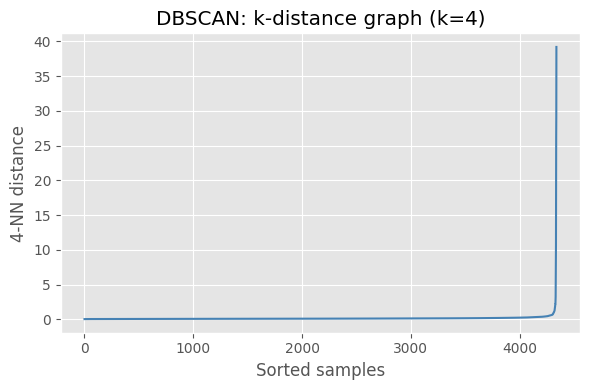

DBSCAN — n_clusters: 3, noise points: 54 (1.2%)


In [11]:
# ==============================================================================
# DBSCAN: k-distance graph to determine eps
# ==============================================================================
nbrs = NearestNeighbors(n_neighbors=4).fit(X)
distances, _ = nbrs.kneighbors(X)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(kdist, color='steelblue')
plt.xlabel('Sorted samples')
plt.ylabel('4-NN distance')
plt.title('DBSCAN: k-distance graph (k=4)')
plt.tight_layout()
plt.show()

t0 = time()
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X)
elapsed = time() - t0

labels_db = dbscan.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()

sil_db = silhouette_score(X, labels_db) if n_clusters_db > 1 else np.nan
db_db  = davies_bouldin_score(X, labels_db) if n_clusters_db > 1 else np.nan
ch_db  = calinski_harabasz_score(X, labels_db) if n_clusters_db > 1 else np.nan

results['algorithm'].append('DBSCAN')
results['n_clusters'].append(n_clusters_db)
results['silhouette'].append(sil_db)
results['davies_bouldin'].append(db_db)
results['calinski_harabasz'].append(ch_db)
results['time'].append(elapsed)
results['labels'].append(labels_db)

print(f"DBSCAN — n_clusters: {n_clusters_db}, noise points: {n_noise} ({n_noise/len(labels_db)*100:.1f}%)")

In [12]:
# Algorithm comparison table
results_df = pd.DataFrame(results).drop(columns=['labels'])
results_df = results_df.sort_values('silhouette', ascending=False)

display(
    results_df.style
    .highlight_max(subset=['silhouette', 'calinski_harabasz'], color='lightgreen')
    .highlight_min(subset=['davies_bouldin'], color='lightgreen')
    .format({
        'silhouette': '{:.4f}',
        'davies_bouldin': '{:.4f}',
        'calinski_harabasz': '{:.1f}',
        'time': '{:.3f}s'
    })
)

# Rebuild results_df with labels for downstream use
results_df_full = pd.DataFrame(results)

,algorithm,n_clusters,silhouette,davies_bouldin,calinski_harabasz,time
0,KMeans 2 n_clusters,2,0.9692,0.1996,4298.9,0.072s
13,Hierarchical (average),4,0.9232,0.1762,1993.5,0.351s
12,Hierarchical (complete),4,0.8663,0.2826,2805.3,0.322s
1,KMeans 3 n_clusters,3,0.6623,0.5289,4994.5,0.079s
2,KMeans 4 n_clusters,4,0.5295,0.5913,5218.0,0.100s
11,Hierarchical (ward),4,0.4722,0.6387,4880.1,0.356s
3,KMeans 5 n_clusters,5,0.4334,0.6394,5898.5,0.101s
5,KMeans 7 n_clusters,7,0.4222,0.5678,6548.4,0.077s
4,KMeans 6 n_clusters,6,0.4199,0.6634,6330.0,0.087s
6,KMeans 8 n_clusters,8,0.4142,0.5762,7129.2,0.090s


## 7. Cluster Analysis & Visualization

Based on the comparison table above, the best-performing configuration is selected by highest Silhouette Score. All four visualizations are applied to that model's cluster labels.

**Visualization suite:**
- PCA 2D scatter: projects the 3D RFM space into 2 principal components.
- PCA 3D scatter: interactive 3D projection (requires plotly).
- Radar chart: normalized mean RFM profile per cluster.
- Feature heatmap: normalized feature values averaged by cluster.
- Value distribution: customer count, monetary box plot, and revenue share per cluster.

In [13]:
# ==============================================================================
# VISUALIZATION HELPER FUNCTIONS
# ==============================================================================

def pca_for_plot(X, min_components=2, target_variance=0.80):
    """Fit PCA retaining at least target_variance, minimum min_components."""
    pca_var = PCA(n_components=target_variance, svd_solver='full')
    n_by_var = pca_var.fit_transform(X).shape[1]
    n_final = max(n_by_var, min_components)
    pca = PCA(n_components=n_final)
    X_pca = pca.fit_transform(X)
    return X_pca, pca


def plot_pca2d(row, X):
    """PCA 2D scatter plot colored by cluster label."""
    labels = np.array(row['labels'])
    X_pca, pca = pca_for_plot(X, min_components=2)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.title(f"PCA 2D — {row['algorithm']}")
    plt.colorbar(scatter, label='Cluster')

    for cid in np.unique(labels):
        centroid = X_pca[labels == cid].mean(axis=0)
        plt.scatter(centroid[0], centroid[1], c='black', marker='X', s=120, zorder=5)

    plt.tight_layout()
    plt.show()


def plot_pca3d(row, X):
    """Interactive PCA 3D scatter plot using plotly."""
    labels = np.array(row['labels'])
    X_pca, pca = pca_for_plot(X, min_components=3)

    fig = px.scatter_3d(
        x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2],
        color=labels.astype(str),
        title=f"PCA 3D — {row['algorithm']}",
        labels={'x': f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
                'y': f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
                'z': f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"},
        opacity=0.6
    )
    fig.show()


def plot_radar(row, rfm):
    """Normalized radar chart of mean RFM per cluster."""
    labels = np.array(row['labels'])
    rfm_copy = rfm.copy()
    rfm_copy['cluster'] = labels
    cluster_ids = np.unique(labels)
    rfm_features = ['Recency', 'Frequency', 'Monetary_log']

    cluster_means = np.array([
        rfm_copy[rfm_copy['cluster'] == cid][rfm_features].mean().values
        for cid in cluster_ids
    ])
    cluster_means_scaled = MinMaxScaler().fit_transform(cluster_means)

    fig = go.Figure()
    for i, cid in enumerate(cluster_ids):
        vals = cluster_means_scaled[i].tolist()
        vals += vals[:1]
        fig.add_trace(go.Scatterpolar(
            r=vals, theta=rfm_features + [rfm_features[0]],
            fill='toself', name=f'Cluster {cid}', opacity=0.6
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        title=f"Radar Chart — {row['algorithm']}",
        showlegend=True
    )
    fig.show()


def plot_heatmap(row, rfm, X, feature_names):
    """Heatmap of normalized mean feature values per cluster."""
    labels = np.array(row['labels'])
    X_scaled = MinMaxScaler().fit_transform(X)
    rfm_norm = pd.DataFrame(X_scaled, columns=feature_names, index=rfm['CustomerID'])
    rfm_norm['cluster'] = labels
    mean_by_cluster = rfm_norm.groupby('cluster').mean()

    plt.figure(figsize=(10, max(3, len(mean_by_cluster) * 0.7)))
    sns.heatmap(
        mean_by_cluster.T, annot=True, fmt='.2f', cmap='coolwarm',
        linewidths=0.2, cbar_kws={'label': 'Normalized value'}
    )
    plt.title(f"Feature Heatmap by Cluster — {row['algorithm']}", fontsize=14)
    plt.ylabel('Feature')
    plt.xlabel('Cluster')
    plt.yticks(rotation=0)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    print(f"\nNormalized means by cluster:")
    display(mean_by_cluster.round(3))


def plot_value_distribution(row, rfm):
    """Bar chart, box plot, and pie chart of cluster value distribution."""
    labels = row['labels']
    rfm_copy = rfm.copy()
    rfm_copy['cluster'] = labels
    cluster_ids = sorted(rfm_copy['cluster'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Customer count per cluster
    counts = rfm_copy['cluster'].value_counts().reindex(cluster_ids)
    counts.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title(f"Customers per Cluster — {row['algorithm']}")
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('Number of customers')
    axes[0].tick_params(axis='x', rotation=0)

    # Monetary box plot
    sns.boxplot(x='cluster', y='Monetary', data=rfm_copy, ax=axes[1], order=cluster_ids)
    axes[1].set_title(f"Monetary Distribution by Cluster — {row['algorithm']}")
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('Monetary (£)')

    plt.tight_layout()
    plt.show()

    # Revenue share pie chart
    revenue = rfm_copy.groupby('cluster')['Monetary'].sum().reindex(cluster_ids)
    fig2, ax2 = plt.subplots(figsize=(6, 6))
    ax2.pie(revenue, labels=cluster_ids, autopct='%1.1f%%', startangle=90)
    ax2.set_title(f"Revenue Share by Cluster — {row['algorithm']}")
    plt.tight_layout()
    plt.show()

    # Summary table
    summary = pd.DataFrame({
        'Cluster': cluster_ids,
        'Customers': counts.values,
        'Total Revenue (£)': revenue.values.round(0),
        'Revenue %': (revenue.values / revenue.sum() * 100).round(1)
    })
    print(f"\nRevenue breakdown by cluster:")
    display(summary)

In [14]:
# Select the best model by highest Silhouette Score
best_idx = results_df_full['silhouette'].idxmax()
best_row = results_df_full.iloc[best_idx]

print(f"Best model   : {best_row['algorithm']}")
print(f"n_clusters   : {best_row['n_clusters']}")
print(f"Silhouette   : {best_row['silhouette']:.4f}")
print(f"Davies-Bouldin: {best_row['davies_bouldin']:.4f}")
print(f"Cal-Harabasz : {best_row['calinski_harabasz']:.1f}")

Best model   : KMeans 2 n_clusters
n_clusters   : 2
Silhouette   : 0.9692
Davies-Bouldin: 0.1996
Cal-Harabasz : 4298.9


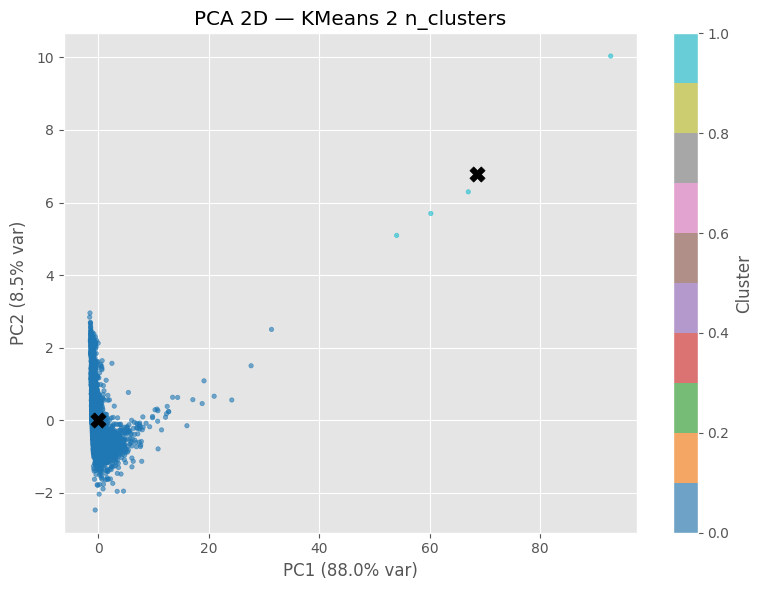

In [15]:
# PCA 2D
plot_pca2d(best_row, X)

In [16]:
# PCA 3D
plot_pca3d(best_row, X)

In [17]:
# Radar chart
plot_radar(best_row, rfm)

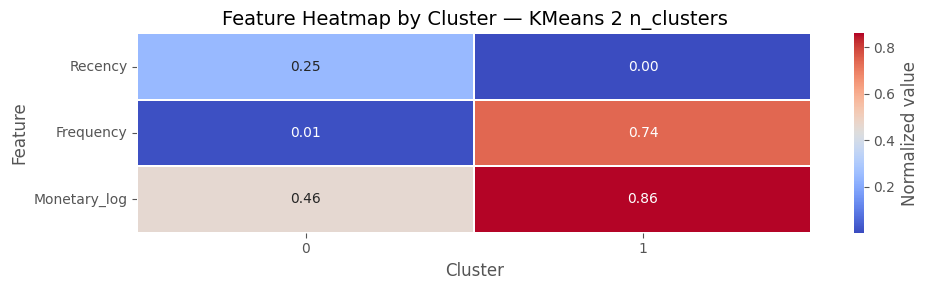


Normalized means by cluster:


,Recency,Frequency,Monetary_log
cluster,,,
0,0.246,0.011,0.458
1,0.003,0.740,0.860


In [18]:
# Feature heatmap
plot_heatmap(best_row, rfm, X, features)

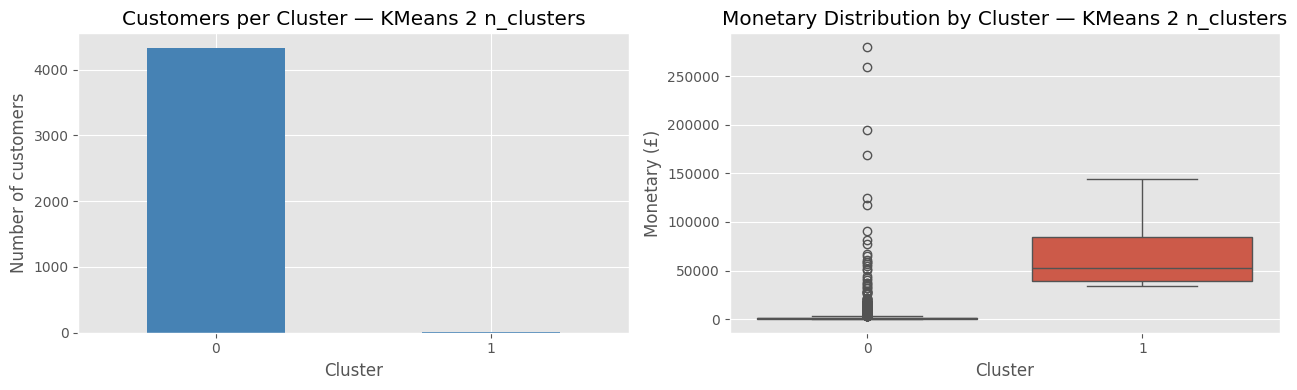

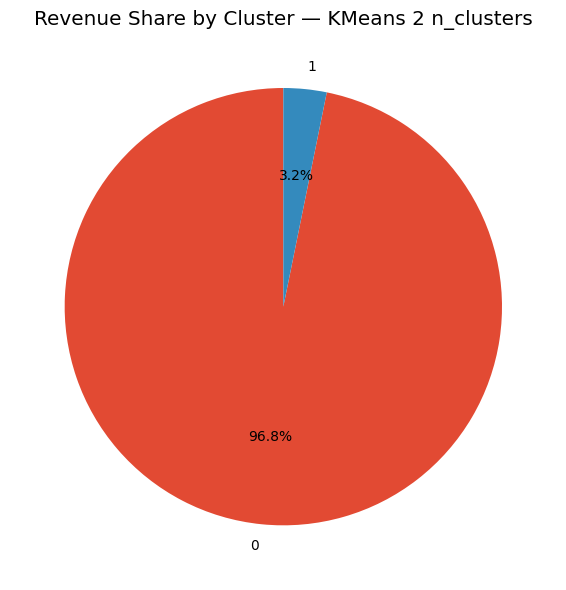


Revenue breakdown by cluster:


,Cluster,Customers,Total Revenue (£),Revenue %
0,0,4334,8627707.0,96.8
1,1,4,283701.0,3.2


In [19]:
# Value distribution (customer count, monetary, revenue share)
plot_value_distribution(best_row, rfm)

## 8. Conclusions & Next Steps

### Key Findings

- After removing 135,080 rows with missing `CustomerID` (24.9%) and invalid `Quantity`/`UnitPrice` entries, the usable dataset was reduced from 541,909 to 397,884 transactions, yielding 4,338 unique customers for RFM analysis.
- RFM distributions are heavily right-skewed: `Frequency` ranges from 1 to 7,847 (median 41) and `Monetary` from £3.75 to £280,206 (median £674.48). Log transformation of `Monetary` was necessary to reduce the influence of extreme spenders before scaling.
- Across 15 configurations tested (K-Means k=2 to 12, Hierarchical with three linkage methods, DBSCAN), K-Means with k=2 produced the highest Silhouette Score (0.9692) and lowest Davies-Bouldin Index (0.1996). However, this result is dominated by 4 extreme-frequency customers who form an isolated outlier cluster, not a meaningful behavioral segment.
- The feature heatmap confirms the binary split: Cluster 1 (4 customers) scores near-maximum on all three normalized dimensions (Recency=0.003, Frequency=0.740, Monetary_log=0.860), while Cluster 0 (4,334 customers) shows moderate recency (0.246), near-zero normalized frequency (0.011), and intermediate log-monetary (0.458).
- Revenue is concentrated in Cluster 0: 4,334 customers account for £8,627,707 (96.8% of total revenue). The 4 outlier customers in Cluster 1 generate £283,701 (3.2%), averaging approximately £70,925 per customer, consistent with wholesale or reseller accounts.

### Model Performance vs. Success Criteria

- The Silhouette Score threshold of >0.30 was exceeded by all 14 configurations with more than one cluster, ranging from 0.9692 (K-Means k=2) down to 0.3179 (K-Means k=12). The criterion of achieving Silhouette > 0.30 is technically met.
- The success criterion of 4 to 6 interpretable segments was not achieved by the automatically selected best model (k=2). The silhouette-based selection is distorted by the outlier cluster of 4 customers, which creates an artificially large inter-cluster distance.
- DBSCAN (eps=0.5, min_samples=5) produced 3 clusters with 54 noise points (1.2%) but scored Silhouette=0.2200 and Davies-Bouldin=9.635, indicating highly imbalanced, elongated cluster shapes incompatible with density-based detection in this feature space.
- Hierarchical clustering with average linkage at k=4 (Silhouette=0.9232, DB=0.1762) provides the closest alignment with the business objective, offering four segments while preserving strong internal separation metrics.

### Interpretation

- The K-Means k=2 partition does not map to classical RFM archetypes. Cluster 1 represents a micro-segment of 4 ultra-high-frequency accounts, most plausibly wholesale resellers or internal test accounts, not a behavioral customer profile suitable for CRM targeting.
- Cluster 0 encompasses the entire mass of 4,334 retail customers with heterogeneous purchasing behavior lumped into a single undifferentiated group. This segment contains both active and dormant customers, high and low spenders, and cannot be used directly for targeted campaigns without further subdivision.
- For business application, the k=4 configuration (K-Means Silhouette=0.5295, DB=0.5913 or Hierarchical average Silhouette=0.9232, DB=0.1762) would produce segments that map more naturally to Champions (low recency, high frequency, high monetary), Loyal (moderate recency and frequency), At Risk (high recency, declining frequency), and Lost/Dormant (maximum recency, minimal frequency and monetary).

### Limitations

- The 24.9% exclusion rate from missing `CustomerID` values likely removes occasional, single-purchase, or guest-checkout buyers from the analysis. The retained customer base is biased toward repeat purchasers, making the RFM profiles unrepresentative of the full customer population.
- Silhouette-based automated model selection is sensitive to extreme outliers. The 4 customers with anomalously high frequency and monetary values inflate the inter-cluster distance for k=2, producing a misleadingly high score that does not reflect segmentation quality for the remaining 99.9% of customers.
- The Calinski-Harabasz index consistently favors higher k values (k=12 scores 7,622 vs. k=2 at 4,299), in direct conflict with the Silhouette ordering. This disagreement between metrics indicates that no single k cleanly resolves the cluster structure, and the data does not exhibit well-separated spherical clusters beyond the outlier effect.
- The dataset covers one calendar year (December 2010 to December 2011). Recency is computed relative to the snapshot date 2011-12-10, placing all customers in the pre-holiday period. No seasonality correction is applied, meaning recency values for December purchasers are systematically lower than those of customers with equivalent engagement patterns in other months.
- All three RFM features are derived solely from transaction records. Behavioral signals such as product category diversity, return rate, or browsing patterns are absent, limiting the depth of each segment's profile.

### Next Steps

- Apply outlier removal or Winsorization (e.g., capping `Frequency` and `Monetary` at the 99th percentile) before clustering to prevent 4 extreme accounts from dominating the partition structure. Re-run all algorithms and re-evaluate model selection with the cleaned distribution.
- Use k=4 with Hierarchical average linkage as the primary business segmentation model. Map the four resulting clusters to Champions, Loyal, At Risk, and Lost archetypes using the radar chart profiles, and build a cluster-specific CRM action plan based on revenue share and RFM centroids.
- Implement quintile-based RFM scoring (1 to 5 per dimension, summed to an RFM score of 3 to 15) as a rule-based baseline, and measure the agreement between score-based segments and unsupervised cluster assignments using the Adjusted Rand Index.
- Enrich the feature space with derived behavioral variables: average basket size (Monetary divided by Frequency), inter-purchase interval variance, product category entropy, and return rate. These additions may improve cluster separability and segment interpretability beyond the current 3-dimensional RFM space.
- Implement rolling-window segmentation (quarterly snapshots) to track customer transitions between segments over time and identify early churn signals, particularly customers migrating from Loyal to At Risk based on deteriorating Recency.
- Investigate whether the 4 outlier customers in Cluster 1 are wholesale accounts or data anomalies. If confirmed as a distinct channel, separate the wholesale segment from retail customers before re-running the segmentation to obtain cleaner retail-only profiles.